# EDA - Análisis después de la limpieza
Validar que la limpieza funcionó correctamente y que los datos limpios estan listos para feature engineering.

In [13]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar raiz al Path
current_dir = Path.cwd().resolve()
for parent in current_dir.parents:
    if (parent / "config.py").exists():
        sys.path.insert(0, str(parent))
        break

from config import (
    ANIOS_PROCESAR,
    PROCESSED_PATHS,
    logger,
)

### Carga y compara antes y después

In [14]:
comparativa = {}

for anio in ANIOS_PROCESAR:
    try:
        df_raw = pd.read_parquet(PROCESSED_PATHS[f"consolidated_{anio}"])
        df_clean = pd.read_parquet(PROCESSED_PATHS[f"cleaned_{anio}"])
        
        filas_eliminadas = len(df_raw) - len(df_clean)
        pct_filas = (filas_eliminadas / len(df_raw)) * 100
        
        memoria_reduccion = 1 - (df_clean.memory_usage(deep=True).sum() / df_raw.memory_usage(deep=True).sum())
        
        comparativa[anio] = {
            'filas_antes': len(df_raw),
            'filas_despues': len(df_clean),
            'filas_eliminadas': filas_eliminadas,
            'pct_filas': pct_filas,
            'cols_antes': df_raw.shape[1],
            'cols_despues': df_clean.shape[1],
            'memoria_antes': df_raw.memory_usage(deep=True).sum() / (1024**2),
            'memoria_despues': df_clean.memory_usage(deep=True).sum() / (1024**2),
            'pct_memoria': memoria_reduccion * 100
        }
        
        print(f"\n {anio}")
        print(f"  ANTES:  {len(df_raw):,} filas × {df_raw.shape[1]} cols × {df_raw.memory_usage(deep=True).sum() / (1024**2):7.1f} MB")
        print(f"  DESPUÉS: {len(df_clean):,} filas × {df_clean.shape[1]} cols × {df_clean.memory_usage(deep=True).sum() / (1024**2):7.1f} MB")
        print(f"  Filas eliminadas: {filas_eliminadas:,} ({pct_filas:.1f}%)")
        print(f"  Reducción memoria: {memoria_reduccion*100:.1f}%")
    except Exception as e:
        print(f"   Error: {e}")


 2022
  ANTES:  1,731,201 filas × 70 cols ×  1655.9 MB
  DESPUÉS: 1,731,201 filas × 16 cols ×   484.8 MB
  Filas eliminadas: 0 (0.0%)
  Reducción memoria: 70.7%

 2023
  ANTES:  2,029,314 filas × 70 cols ×  2427.6 MB
  DESPUÉS: 2,029,314 filas × 16 cols ×   575.2 MB
  Filas eliminadas: 0 (0.0%)
  Reducción memoria: 76.3%

 2024
  ANTES:  2,194,444 filas × 70 cols ×  2580.4 MB
  DESPUÉS: 2,194,441 filas × 16 cols ×   616.3 MB
  Filas eliminadas: 3 (0.0%)
  Reducción memoria: 76.1%

 2025
  ANTES:  2,231,647 filas × 70 cols ×  2597.9 MB
  DESPUÉS: 2,231,637 filas × 16 cols ×   613.8 MB
  Filas eliminadas: 10 (0.0%)
  Reducción memoria: 76.4%

 2026
  ANTES:  1,347,972 filas × 70 cols ×  1540.7 MB
  DESPUÉS: 1,347,966 filas × 16 cols ×   370.7 MB
  Filas eliminadas: 6 (0.0%)
  Reducción memoria: 75.9%


### Gráfico: Impacto de la limpieza

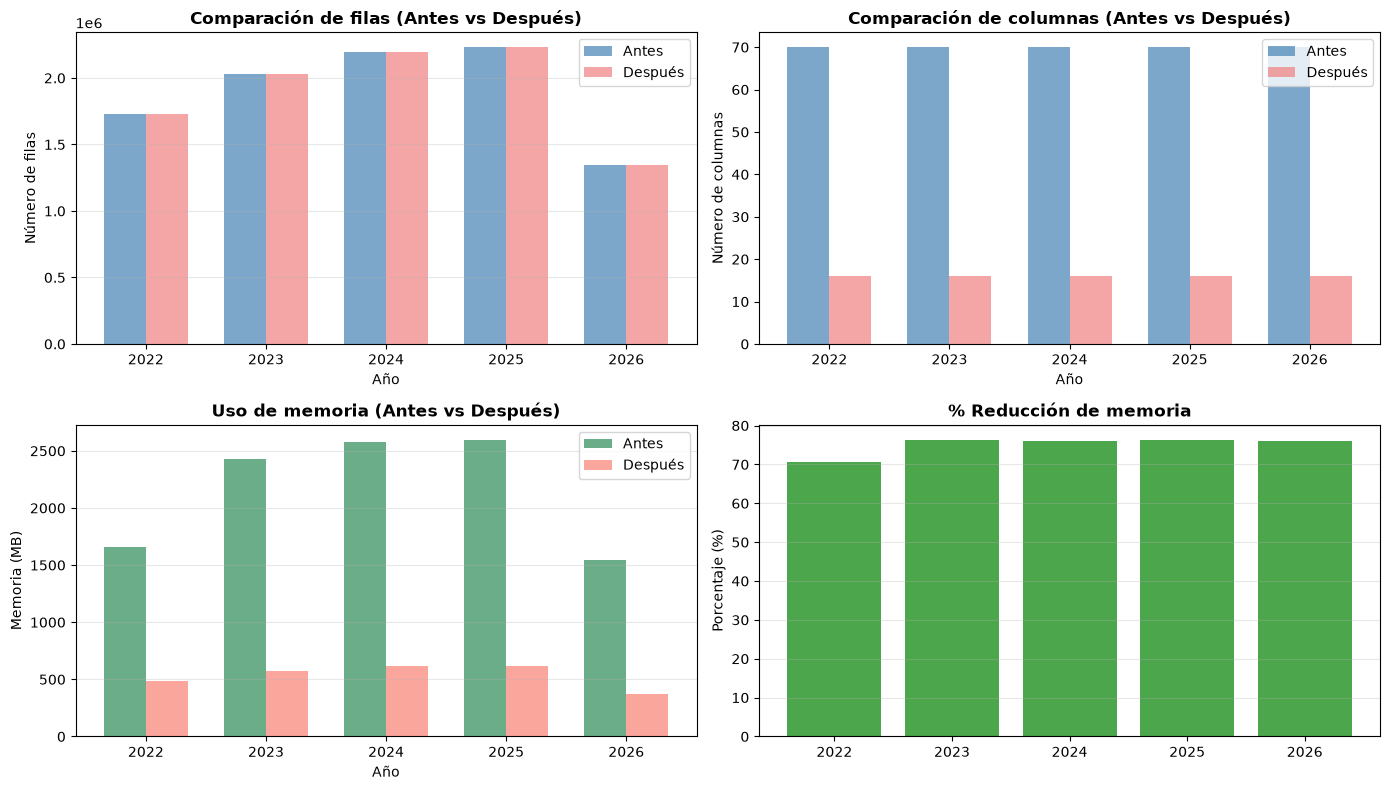

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

anios = list(comparativa.keys())

# Gráfico 1: Filas antes/después
x = np.arange(len(anios))
width = 0.35
filas_antes = [comparativa[a]['filas_antes'] for a in anios]
filas_despues = [comparativa[a]['filas_despues'] for a in anios]

axes[0, 0].bar(x - width/2, filas_antes, width, label='Antes', color='steelblue', alpha=0.7)
axes[0, 0].bar(x + width/2, filas_despues, width, label='Después', color='lightcoral', alpha=0.7)
axes[0, 0].set_xlabel('Año')
axes[0, 0].set_ylabel('Número de filas')
axes[0, 0].set_title('Comparación de filas (Antes vs Después)', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(anios)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')

# Gráfico 2: Columnas antes/después
cols_antes = [comparativa[a]['cols_antes'] for a in anios]
cols_despues = [comparativa[a]['cols_despues'] for a in anios]

axes[0, 1].bar(x - width/2, cols_antes, width, label='Antes', color='steelblue', alpha=0.7)
axes[0, 1].bar(x + width/2, cols_despues, width, label='Después', color='lightcoral', alpha=0.7)
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Número de columnas')
axes[0, 1].set_title('Comparación de columnas (Antes vs Después)', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(anios)
axes[0, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

# Gráfico 3: Memoria antes/después
mem_antes = [comparativa[a]['memoria_antes'] for a in anios]
mem_despues = [comparativa[a]['memoria_despues'] for a in anios]

axes[1, 0].bar(x - width/2, mem_antes, width, label='Antes', color='seagreen', alpha=0.7)
axes[1, 0].bar(x + width/2, mem_despues, width, label='Después', color='salmon', alpha=0.7)
axes[1, 0].set_xlabel('Año')
axes[1, 0].set_ylabel('Memoria (MB)')
axes[1, 0].set_title('Uso de memoria (Antes vs Después)', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(anios)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis='y')

# Gráfico 4: % Reducción de memoria
pct_reduccion = [comparativa[a]['pct_memoria'] for a in anios]
colors = ['green' if p > 0 else 'red' for p in pct_reduccion]
axes[1, 1].bar(anios, pct_reduccion, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('Porcentaje (%)')
axes[1, 1].set_title('% Reducción de memoria', fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

###  Validar columnas clave

In [16]:
print("\n📊 VALIDACIÓN DE COLUMNAS CLAVE (DESPUÉS DE LIMPIEZA)\n")

clave_data = {}
for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"cleaned_{anio}"])
        
        local_ids = df['local_id'].nunique() if 'local_id' in df.columns else 0
        barrios = df['desc_barrio_local'].nunique() if 'desc_barrio_local' in df.columns else 0
        meses = df['fecha'].nunique() if 'fecha' in df.columns else 0
        nulos = df.isnull().sum().sum()
        
        clave_data[anio] = {
            'local_ids': local_ids,
            'barrios': barrios,
            'meses': meses,
            'nulos': nulos
        }
        
        print(f"  {anio}:")
        print(f"    Local IDs únicos: {local_ids:,}")
        print(f"    Barrios: {barrios}")
        print(f"    Meses: {meses}")
        print(f"    Nulos totales: {nulos:,}")
        
    except Exception as e:
        print(f"    ❌ Error: {e}")


📊 VALIDACIÓN DE COLUMNAS CLAVE (DESPUÉS DE LIMPIEZA)

  2022:
    Local IDs únicos: 150,566
    Barrios: 131
    Meses: 10
    Nulos totales: 0
  2023:
    Local IDs únicos: 151,180
    Barrios: 132
    Meses: 12
    Nulos totales: 0
  2024:
    Local IDs únicos: 201,261
    Barrios: 131
    Meses: 12
    Nulos totales: 0
  2025:
    Local IDs únicos: 202,891
    Barrios: 131
    Meses: 10
    Nulos totales: 0
  2026:
    Local IDs únicos: 203,329
    Barrios: 131
    Meses: 6
    Nulos totales: 0


### Gráfico: Cobertura post-limpieza

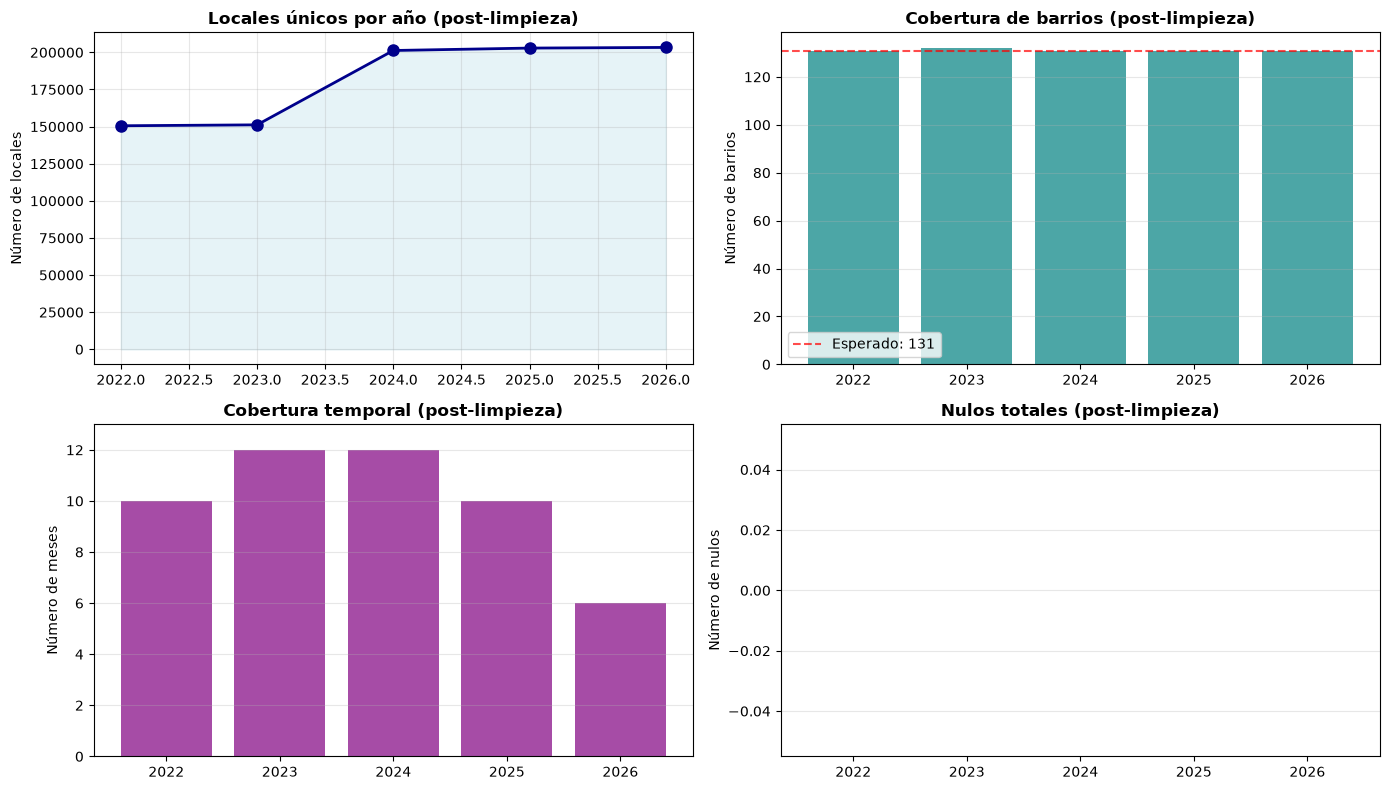

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

anios = list(clave_data.keys())

# Local IDs
local_ids = [clave_data[a]['local_ids'] for a in anios]
axes[0, 0].plot(anios, local_ids, marker='o', linewidth=2, markersize=8, color='darkblue')
axes[0, 0].fill_between(anios, local_ids, alpha=0.3, color='lightblue')
axes[0, 0].set_title('Locales únicos por año (post-limpieza)', fontweight='bold')
axes[0, 0].set_ylabel('Número de locales')
axes[0, 0].grid(alpha=0.3)

# Barrios
barrios = [clave_data[a]['barrios'] for a in anios]
axes[0, 1].bar(anios, barrios, color='teal', alpha=0.7)
axes[0, 1].set_title('Cobertura de barrios (post-limpieza)', fontweight='bold')
axes[0, 1].set_ylabel('Número de barrios')
axes[0, 1].grid(alpha=0.3, axis='y')
axes[0, 1].axhline(y=131, color='red', linestyle='--', label='Esperado: 131', alpha=0.7)
axes[0, 1].legend()

# Meses
meses = [clave_data[a]['meses'] for a in anios]
axes[1, 0].bar(anios, meses, color='purple', alpha=0.7)
axes[1, 0].set_title('Cobertura temporal (post-limpieza)', fontweight='bold')
axes[1, 0].set_ylabel('Número de meses')
axes[1, 0].grid(alpha=0.3, axis='y')
axes[1, 0].set_ylim([0, 13])

# Nulos
nulos = [clave_data[a]['nulos'] for a in anios]
colors_nulos = ['green' if n == 0 else 'orange' for n in nulos]
axes[1, 1].bar(anios, nulos, color=colors_nulos, alpha=0.7)
axes[1, 1].set_title('Nulos totales (post-limpieza)', fontweight='bold')
axes[1, 1].set_ylabel('Número de nulos')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Análisis de nulos 

In [18]:
for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"cleaned_{anio}"])
        nulos_totales = df.isnull().sum().sum()
        
        if nulos_totales == 0:
            print(f"\n{anio}:  SIN NULOS (limpieza perfecta)")
        else:
            print(f"\n{anio}:  {nulos_totales:,} nulos restantes")
            nulos_por_col = df.isnull().sum()
            for col in nulos_por_col[nulos_por_col > 0].index:
                print(f"  - {col}: {nulos_por_col[col]:,}")
        
    except Exception as e:
        print(f"   Error: {e}")



2022:  SIN NULOS (limpieza perfecta)

2023:  SIN NULOS (limpieza perfecta)

2024:  SIN NULOS (limpieza perfecta)

2025:  SIN NULOS (limpieza perfecta)

2026:  SIN NULOS (limpieza perfecta)


### Distribución de hostelería por barrio

In [19]:
for anio in ANIOS_PROCESAR:
    try:
        ultimo_anio = max(ANIOS_PROCESAR)
        df = pd.read_parquet(PROCESSED_PATHS[f"cleaned_{anio}"])
        
        if 'es_hosteleria' in df.columns and 'desc_barrio_local' in df.columns:
            print(f"\n - {anio}")
            
            # Hostelería por barrio
            bares_por_barrio = df[df['es_hosteleria'] == True]['desc_barrio_local'].value_counts().head(10)
            
            for i, (barrio, count) in enumerate(bares_por_barrio.items(), 1):
                print(f"  {i:2d}. {barrio:30s} {count:6,} bares")
        
    except Exception as e:
        print(f"  Error: {e}")



 - 2022
   1. UNIVERSIDAD                     7,466 bares
   2. PALACIO                         7,125 bares
   3. EMBAJADORES                     6,454 bares
   4. JUSTICIA                        6,117 bares
   5. SOL                             5,923 bares
   6. CORTES                          5,418 bares
   7. CUATRO CAMINOS                  4,536 bares
   8. GOYA                            4,334 bares
   9. RECOLETOS                       4,072 bares
  10. TRAFALGAR                       3,872 bares

 - 2023
   1. UNIVERSIDAD                     8,873 bares
   2. PALACIO                         8,367 bares
   3. EMBAJADORES                     7,575 bares
   4. JUSTICIA                        7,204 bares
   5. SOL                             7,037 bares
   6. CORTES                          6,394 bares
   7. CUATRO CAMINOS                  5,316 bares
   8. GOYA                            5,045 bares
   9. RECOLETOS                       4,661 bares
  10. TRAFALGAR                 

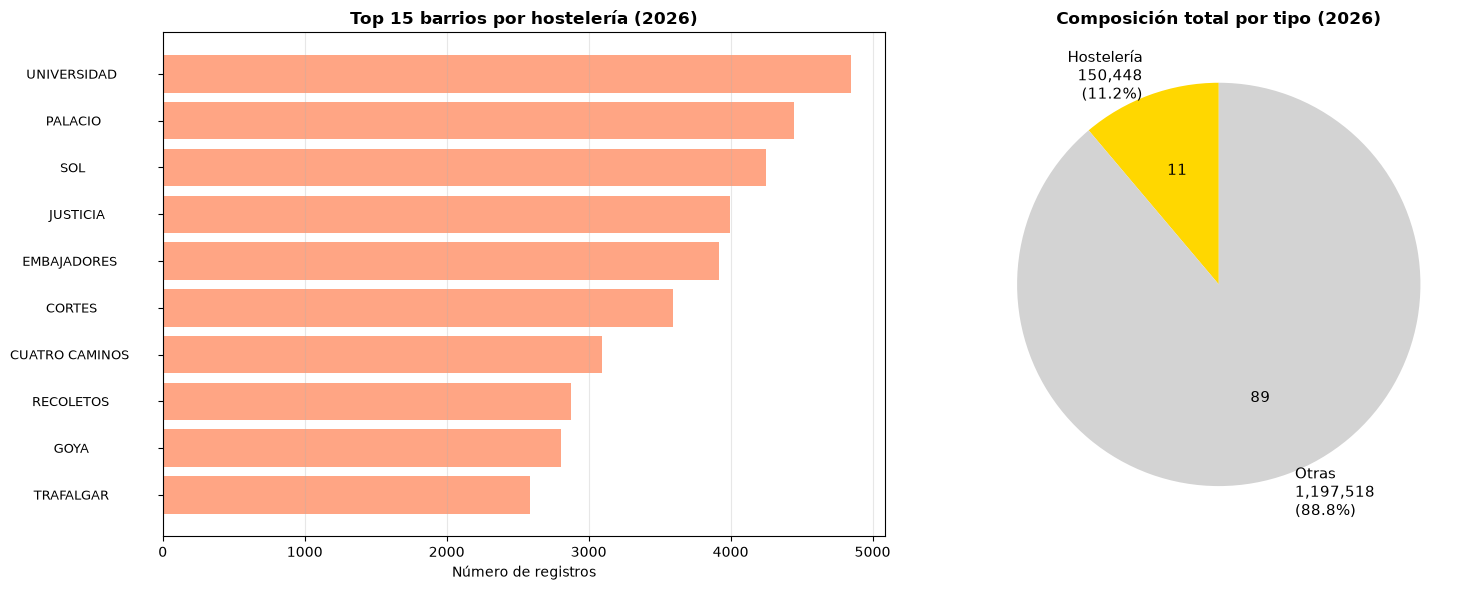

In [20]:
if 'es_hosteleria' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top 15 barrios
    hosteleria_top = bares_por_barrio.head(10)
    axes[0].barh(range(len(hosteleria_top)), hosteleria_top.values, color='coral', alpha=0.7)
    axes[0].set_yticks(range(len(hosteleria_top)))
    axes[0].set_yticklabels(hosteleria_top.index, fontsize=9)
    axes[0].set_xlabel('Número de registros')
    axes[0].set_title(f'Top 15 barrios por hostelería ({ultimo_anio})', fontweight='bold')
    axes[0].grid(alpha=0.3, axis='x')
    axes[0].invert_yaxis()
    
    # Pie chart: Hostelería vs No hostelería
    hostel_count = df['es_hosteleria'].sum()
    no_hostel_count = len(df) - hostel_count
    
    sizes = [hostel_count, no_hostel_count]
    labels = [f'Hostelería\n{hostel_count:,}\n({(hostel_count/len(df))*100:.1f}%)',
              f'Otras\n{no_hostel_count:,}\n({(no_hostel_count/len(df))*100:.1f}%)']
    colors = ['gold', 'lightgray']
    
    axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.0f', startangle=90, textprops={'fontsize': 11})
    axes[1].set_title(f'Composición total por tipo ({ultimo_anio})', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

### Cobertura temporal

In [21]:
for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"cleaned_{anio}"])
        if 'fecha' in df.columns:
            print(f"\n- {anio}")
            fechas = df['fecha'].value_counts().sort_index()
            print(f"  Meses: {len(fechas)}")
            for fecha, count in fechas.items():
                print(f"    - {fecha}: {count:,}")
        
    except Exception as e:
        print(f"  Error: {e}")


- 2022
  Meses: 10
    - 202202: 167,621
    - 202203: 167,474
    - 202205: 167,715
    - 202206: 219,319
    - 202207: 167,905
    - 202208: 167,992
    - 202209: 168,069
    - 202210: 168,282
    - 202211: 168,340
    - 202212: 168,484

- 2023
  Meses: 12
    - 202301: 168,549
    - 202302: 168,622
    - 202303: 168,651
    - 202304: 168,822
    - 202305: 168,945
    - 202306: 169,103
    - 202307: 169,234
    - 202308: 169,339
    - 202309: 169,446
    - 202310: 169,521
    - 202311: 169,522
    - 202312: 169,560

- 2024
  Meses: 12
    - 202401: 169,637
    - 202402: 169,647
    - 202403: 169,657
    - 202404: 169,731
    - 202405: 169,733
    - 202406: 169,916
    - 202407: 170,638
    - 202408: 170,744
    - 202409: 170,853
    - 202410: 221,073
    - 202411: 221,377
    - 202412: 221,435

- 2025
  Meses: 10
    - 202503: 222,236
    - 202504: 222,430
    - 202505: 222,610
    - 202506: 222,905
    - 202507: 223,031
    - 202508: 223,174
    - 202509: 223,422
    - 202510: 223,

### Tipos de datos

In [22]:
for anio in ANIOS_PROCESAR:
    try:
        df = pd.read_parquet(PROCESSED_PATHS[f"cleaned_{anio}"])
        
        print(f"\n- {anio}")
        tipos = df.dtypes.value_counts()
        for tipo, cantidad in tipos.items():
            print(f"  {str(tipo):20s} {cantidad:3d} columnas")
        
    except Exception as e:
        print(f"   Error: {e}")


- 2022
  str                   10 columnas
  int64                  3 columnas
  float64                2 columnas
  bool                   1 columnas

- 2023
  str                   10 columnas
  int64                  3 columnas
  float64                2 columnas
  bool                   1 columnas

- 2024
  str                   10 columnas
  int64                  3 columnas
  float64                2 columnas
  bool                   1 columnas

- 2025
  str                   10 columnas
  int64                  3 columnas
  float64                2 columnas
  bool                   1 columnas

- 2026
  str                   10 columnas
  int64                  3 columnas
  float64                2 columnas
  bool                   1 columnas


In [23]:
df_clean= pd.read_parquet(PROCESSED_PATHS[f"cleaned_2022"])
df =  df_clean.copy()
print(f"nulos antes de la limpieza: {df_clean['coordenada_x_local'].isnull().sum()}")
print(f"total de datos: {df_clean['coordenada_x_local'].sum()}")
df = df.dropna(subset=['coordenada_x_local'])
print(f"Total de datos despues de la limpieza: {df['coordenada_x_local'].isnull().sum()}")

valores_unicos = df_clean['coordenada_x_local'].unique()
print(valores_unicos)

frecuencia_unicos = df_clean['coordenada_x_local'].value_counts()
print(frecuencia_unicos)

nulos antes de la limpieza: 0
total de datos: 710663256022.8815
Total de datos despues de la limpieza: 0
[439532.6  438968.6  442396.58 ... 440144.78 442024.5  446863.84]
coordenada_x_local
0.00         122576
440241.62      3327
450162.56      2241
437367.57      1560
445879.57      1516
              ...  
445431.47         1
443717.97         1
440144.78         1
442024.50         1
446863.84         1
Name: count, Length: 79353, dtype: int64


In [24]:
frecuencia_unicos = df['coordenada_x_local'].value_counts()
print(frecuencia_unicos)

coordenada_x_local
0.00         122576
440241.62      3327
450162.56      2241
437367.57      1560
445879.57      1516
              ...  
445431.47         1
443717.97         1
440144.78         1
442024.50         1
446863.84         1
Name: count, Length: 79353, dtype: int64
